In [51]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import plotly.express as px
import seaborn as sns



In [52]:

df=pd.read_csv('netflix_titles.csv',index_col="show_id")
print(df.shape)
df.head()

(8807, 11)


,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [53]:
df.tail()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [54]:
df.info()

<class 'pandas.DataFrame'>
Index: 8807 entries, s1 to s8807
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          8807 non-null   str  
 1   title         8807 non-null   str  
 2   director      6173 non-null   str  
 3   cast          7982 non-null   str  
 4   country       7976 non-null   str  
 5   date_added    8797 non-null   str  
 6   release_year  8807 non-null   int64
 7   rating        8803 non-null   str  
 8   duration      8804 non-null   str  
 9   listed_in     8807 non-null   str  
 10  description   8807 non-null   str  
dtypes: int64(1), str(10)
memory usage: 825.7+ KB


In [55]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [56]:
df.describe(include="object")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24804\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,2,8807,4528,7692,748,1767,17,220,514,8775
top,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,6131,1,19,19,2818,109,3207,1793,362,4


In [57]:
df.isnull().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [58]:
df.shape

(8807, 11)

In [59]:
df.duplicated()

show_id
s1       False
s2       False
s3       False
s4       False
s5       False
         ...  
s8803    False
s8804    False
s8805    False
s8806    False
s8807    False
Length: 8807, dtype: bool

In [60]:
df.type

show_id
s1         Movie
s2       TV Show
s3       TV Show
s4       TV Show
s5       TV Show
          ...   
s8803      Movie
s8804    TV Show
s8805      Movie
s8806      Movie
s8807      Movie
Name: type, Length: 8807, dtype: str

In [61]:
df.dropna()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
...,...,...,...,...,...,...,...,...,...,...,...
s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...


In [62]:
df.director.fillna('Unknown')

show_id
s1       Kirsten Johnson
s2               Unknown
s3       Julien Leclercq
s4               Unknown
s5               Unknown
              ...       
s8803      David Fincher
s8804            Unknown
s8805    Ruben Fleischer
s8806       Peter Hewitt
s8807        Mozez Singh
Name: director, Length: 8807, dtype: str

In [63]:
df.cast.fillna('no name')


show_id
s1                                                 no name
s2       Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...
s3       Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...
s4                                                 no name
s5       Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...
                               ...                        
s8803    Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...
s8804                                              no name
s8805    Jesse Eisenberg, Woody Harrelson, Emma Stone, ...
s8806    Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...
s8807    Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...
Name: cast, Length: 8807, dtype: str

In [64]:
df.fillna('Unknown', inplace=True)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...


In [65]:
df.release_year.mode()[0],df.release_year.median(),df.release_year.mean(),df.release_year.min(),df.release_year.max(),df.release_year.mean()

(np.int64(2018),
 np.float64(2017.0),
 np.float64(2014.1801975701146),
 np.int64(1925),
 np.int64(2021),
 np.float64(2014.1801975701146))

In [66]:
df["release_year"].quantile([0.05,0.25,0.5,0.75,0.95])

0.05    1997.0
0.25    2013.0
0.50    2017.0
0.75    2019.0
0.95    2021.0
Name: release_year, dtype: float64

In [67]:
df.release_year.std() #среднее отклонение 

np.float64(8.819312130833966)

In [68]:
df["release_year"].var(),df["release_year"].skew(),df["release_year"].kurtosis()

(np.float64(77.78026646107516),
 np.float64(-3.4465650403316013),
 np.float64(16.232225648417078))

In [69]:
df.type.unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [70]:
df_encoded = pd.get_dummies(df, columns=['type'])
print("\nПосле pd.get_dummies:")
df_encoded.head()


После pd.get_dummies:


,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type_Movie,type_TV Show
show_id,,,,,,,,,,,,
s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",True,False
s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",False,True
s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,False,True
s4,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",False,True
s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,False,True


In [71]:
df_encoded = pd.get_dummies(df, columns=['type'], drop_first=True)
print("\nПосле pd.get_dummies:")
df_encoded.head()


После pd.get_dummies:


,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type_TV Show
show_id,,,,,,,,,,,
s1,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",False
s2,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",True
s3,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,True
s4,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",True
s5,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,True


In [72]:
''' categorical_cols = ['type']
df_clean = df.reset_index(drop=True)

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df_clean[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols)
)

df_final = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)

print(df_final) '''

# OneHotCoding



" categorical_cols = ['type']\ndf_clean = df.reset_index(drop=True)\n\nencoder = OneHotEncoder(sparse_output=False)\n\nencoded = encoder.fit_transform(df_clean[categorical_cols])\n\nencoded_df = pd.DataFrame(\n    encoded,\n    columns=encoder.get_feature_names_out(categorical_cols)\n)\n\ndf_final = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)\n\nprint(df_final) "

In [73]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
Index: 8807 entries, s1 to s8807
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          8807 non-null   str  
 1   title         8807 non-null   str  
 2   director      8807 non-null   str  
 3   cast          8807 non-null   str  
 4   country       8807 non-null   str  
 5   date_added    8807 non-null   str  
 6   release_year  8807 non-null   int64
 7   rating        8807 non-null   str  
 8   duration      8807 non-null   str  
 9   listed_in     8807 non-null   str  
 10  description   8807 non-null   str  
dtypes: int64(1), str(10)
memory usage: 8.3 MB


In [74]:
import category_encoders as ce 
encoder = ce.TargetEncoder(cols=['country'])
df['country_target'] = encoder.fit_transform(df['country'], df['release_year'])
print(df['country_target'])

show_id
s1       2013.314762
s2       2016.558430
s3       2017.008424
s4       2017.008424
s5       2011.966049
            ...     
s8803    2013.314762
s8804    2017.008424
s8805    2013.314762
s8806    2013.314762
s8807    2011.966049
Name: country_target, Length: 8807, dtype: float64


In [75]:
df.describe()

,release_year,country_target
count,8807.000000,8807.000000
mean,2014.180198,2014.198401
std,8.819312,2.271051
min,1925.000000,1998.575549
25%,2013.000000,2013.314762
50%,2017.000000,2013.516307
75%,2019.000000,2015.894442
max,2021.000000,2018.168474


In [76]:
encoder = ce.HashingEncoder(cols=['country'], n_components=8)
df_hashed = encoder.fit_transform(df[['country']], y=None)
df_hashed['country'] = df['country']
print(df_hashed.head())


         col_0  col_1  col_2  col_3  col_4  col_5  col_6  col_7        country
show_id                                                                       
s1           0      1      0      0      0      0      0      0  United States
s2           1      0      0      0      0      0      0      0   South Africa
s3           0      0      0      0      0      0      1      0        Unknown
s4           0      0      0      0      0      0      1      0        Unknown
s5           0      0      0      1      0      0      0      0          India


In [77]:
df.head(3)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,country_target
show_id,,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2013.314762
s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2016.558430
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2017.008424


In [78]:
df['month_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.month
df['month_added'].head()

show_id
s1    9.0
s2    9.0
s3    9.0
s4    9.0
s5    9.0
Name: month_added, dtype: float64

In [79]:

actor_counts = df['cast'].dropna().str.split(',').explode().str.strip().value_counts()

print(actor_counts.head(10))

cast
Unknown             825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Name: count, dtype: int64


In [80]:
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float) 
df['duration_int']

show_id
s1        90.0
s2         2.0
s3         1.0
s4         1.0
s5         2.0
         ...  
s8803    158.0
s8804      2.0
s8805     88.0
s8806     88.0
s8807    111.0
Name: duration_int, Length: 8807, dtype: float64

In [81]:
df.head(3)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,country_target,month_added,duration_int
show_id,,,,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2013.314762,9.0,90.0
s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2016.558430,9.0,2.0
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2017.008424,9.0,1.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24804\335503590.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='duration_int', palette='Reds')


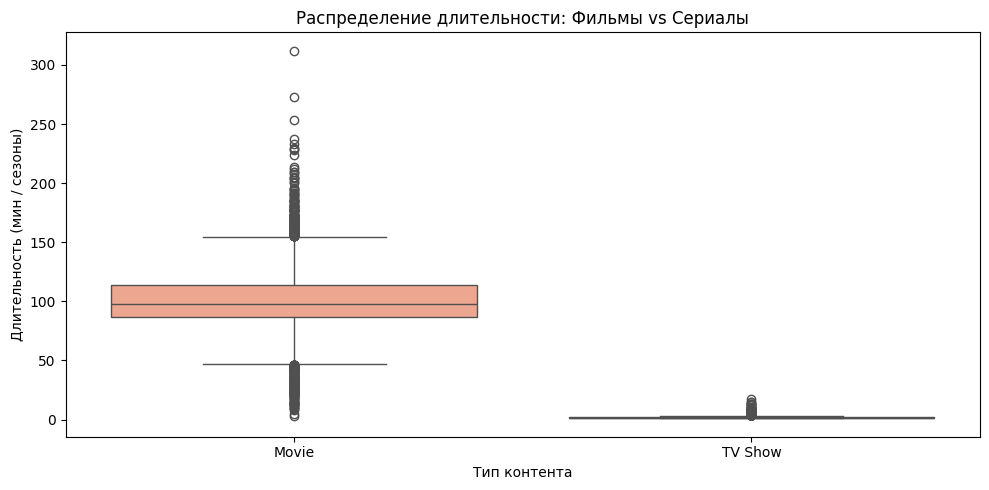

In [82]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='type', y='duration_int', palette='Reds')
plt.title('Распределение длительности: Фильмы vs Сериалы')
plt.xlabel('Тип контента')
plt.ylabel('Длительность (мин / сезоны)')
plt.tight_layout()
plt.show() 

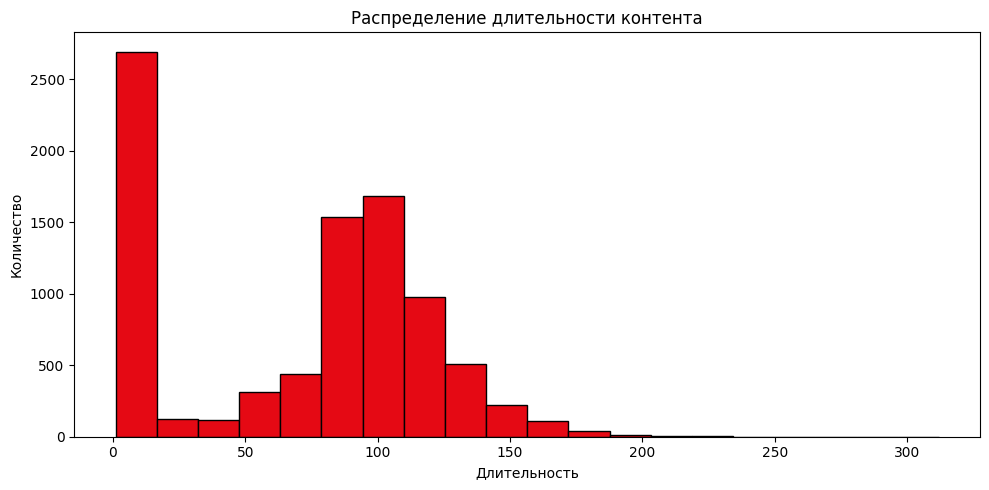

In [83]:
plt.figure(figsize=(10, 5))
plt.hist(df['duration_int'].dropna(), bins=20, color='#E50914', edgecolor='black')
plt.title('Распределение длительности контента')
plt.xlabel('Длительность')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'release_year'}>,
        <Axes: title={'center': 'country_target'}>],
       [<Axes: title={'center': 'month_added'}>,
        <Axes: title={'center': 'duration_int'}>]], dtype=object)

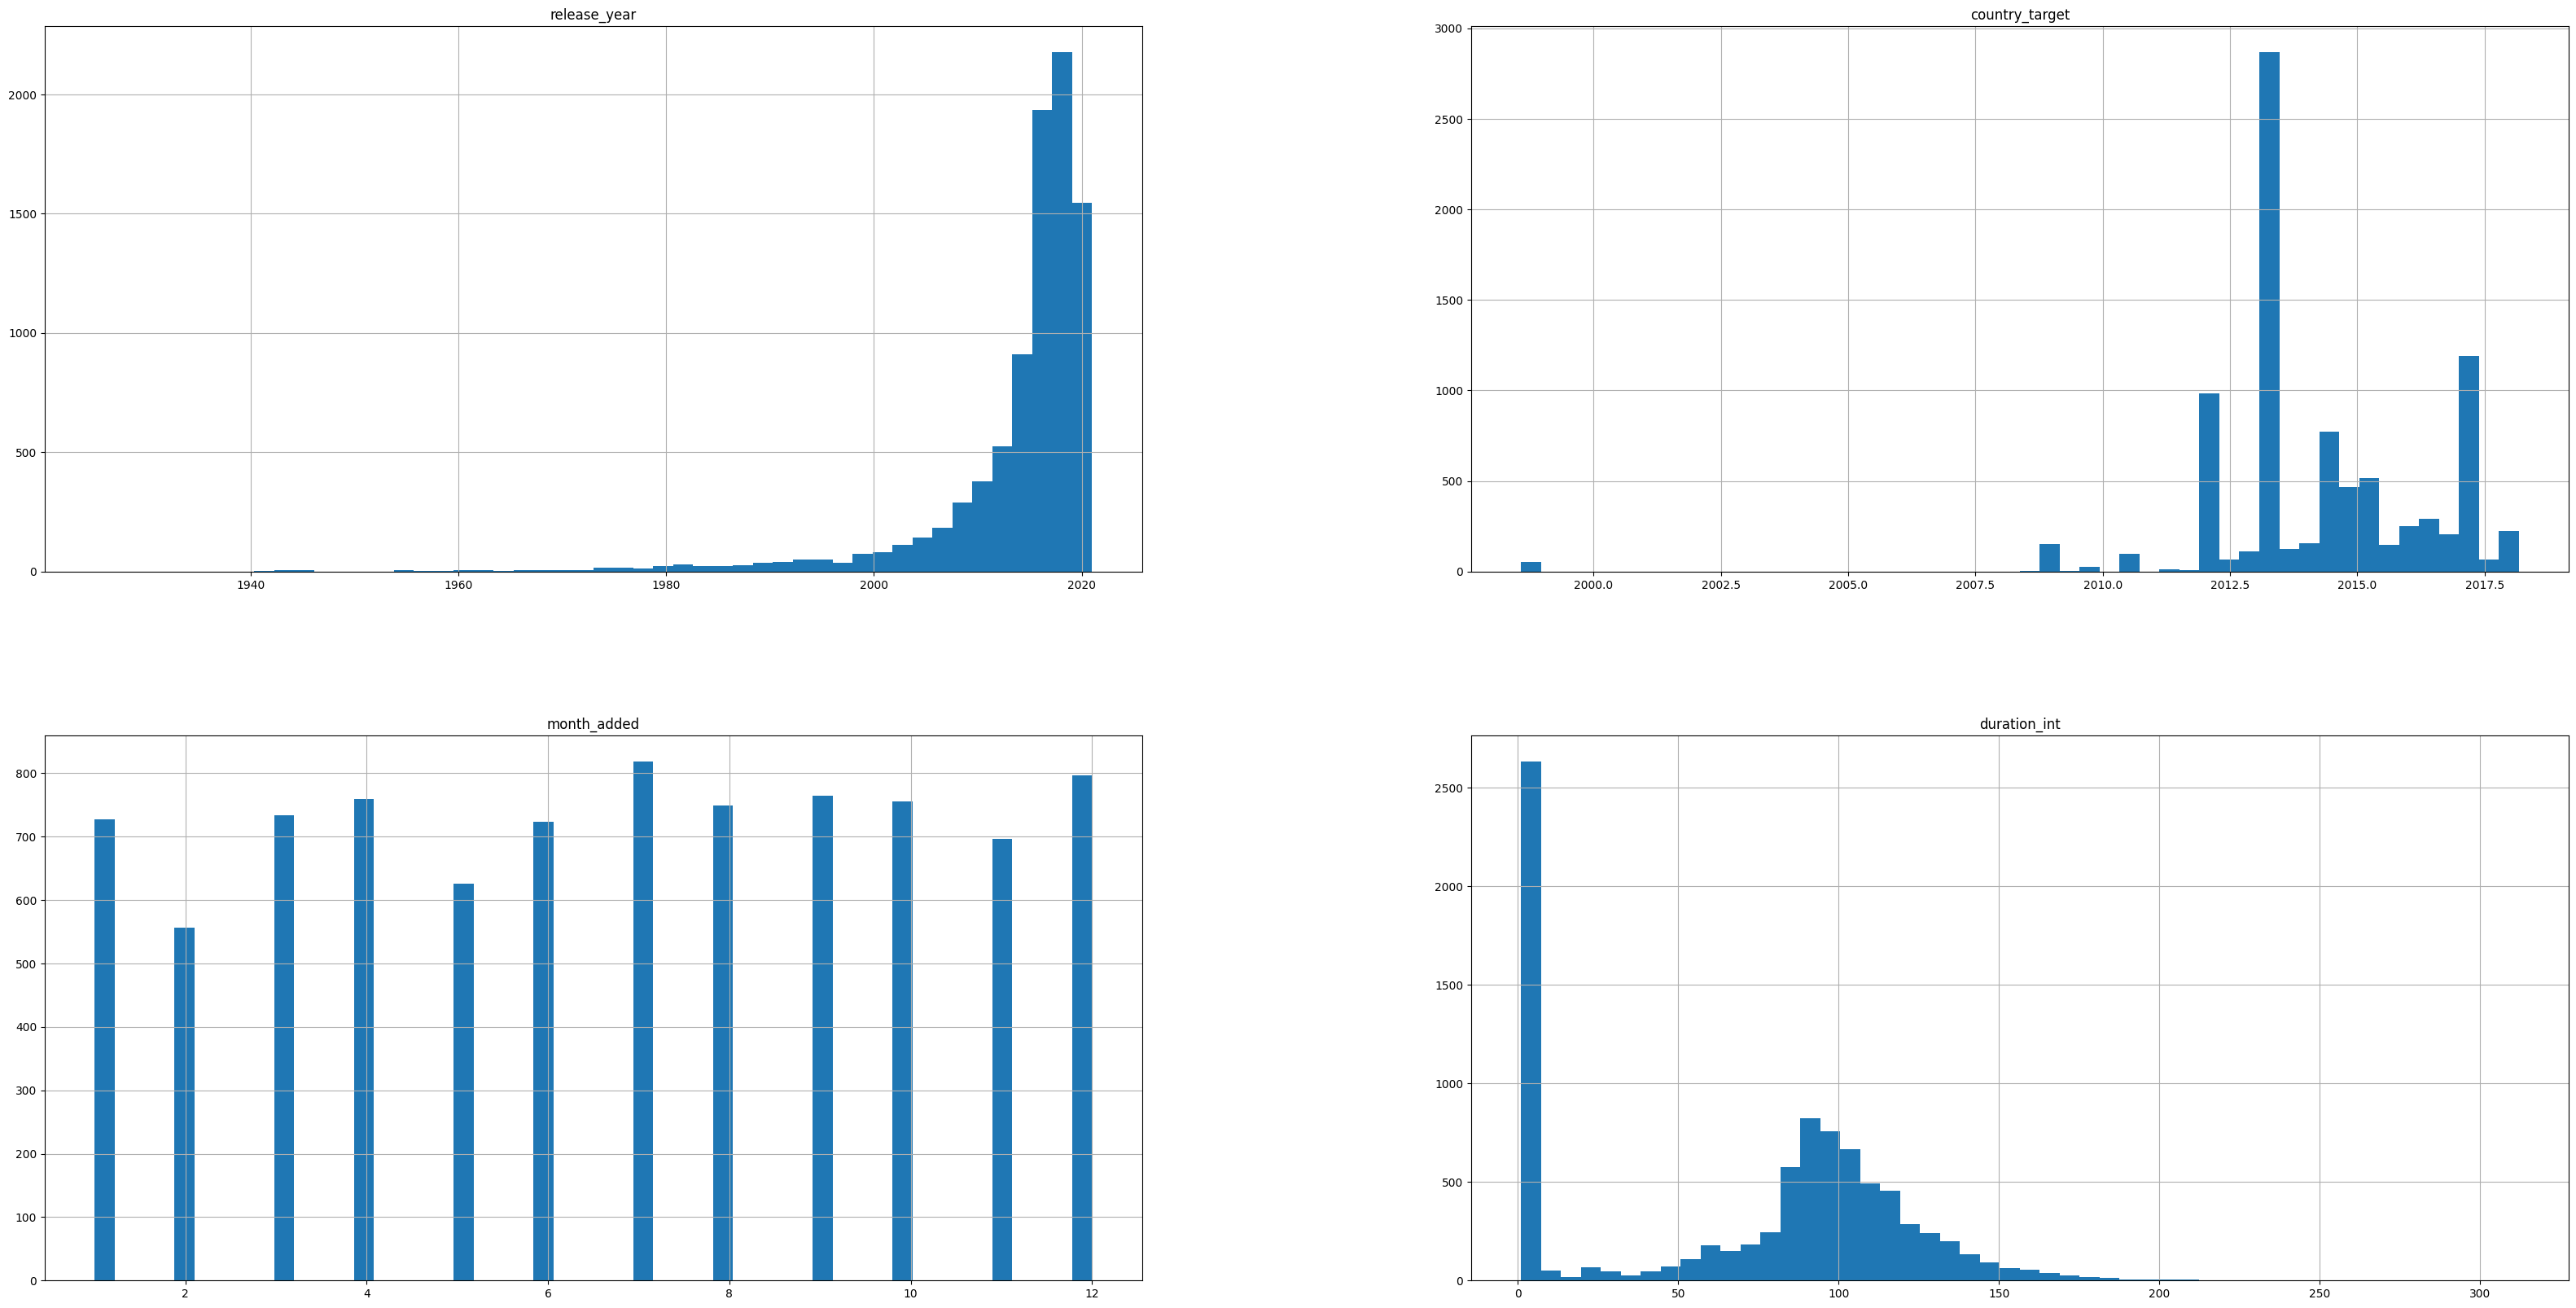

In [84]:
df.hist(bins=50,figsize=(40,20))